Random Forest algorithm is applied to Kaggle- Credit Card Fraud Detection dataset, https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data. The Scikit Learn library is used. The dataset is unbalaced, 492 frauds out of 284,807 transaction. All frauds(positive) are labelled as 1 and the rest is 0 (negatives).  

In [1]:
##importing libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
import pickle

PCA was applied the dataset. The dataset is controlled for any NaN or dublicate values for removal. X and Y values are assigned and dataset is splitted for training and testing. 

In [ ]:
##loading the dataset
credit_card = pd.read_csv('/Users/gulcinecesasmaz/Desktop/Model_engineering/creditcard.csv')
y = credit_card['Class']
X=credit_card.iloc[:,:]
X.drop(['Class'],axis=1,inplace=True)

print(credit_card.describe())
print(credit_card.info())
print(credit_card.isnull().sum())

#Splitting the dataset into train and test
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(credit_card.describe())
print(credit_card.info())
print(credit_card.isnull().sum())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

As a preprocessing on dataset, the Standard Scaler is applied to standardize features by removing the mean and scaling to unit variance from Scikit Learn. 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.8826354754056941
Best parameters: {'classifier__n_estimators': 20, 'classifier__min_samples_split': 4, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None, 'classifier__criterion': 'log_loss'}
Best score: 0.999543549342755
Best estimator: Pipeline(steps=[('standardize', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(criterion='log_loss',
                                        min_samples_leaf=2, min_samples_split=4,
                                        n_estimators=20))])
Precision: 0.974025974025974
Recall: 0.7653061224489796
F1 Score: 0.8571428571428571
Loaded Model Precision: 0.97402597402597

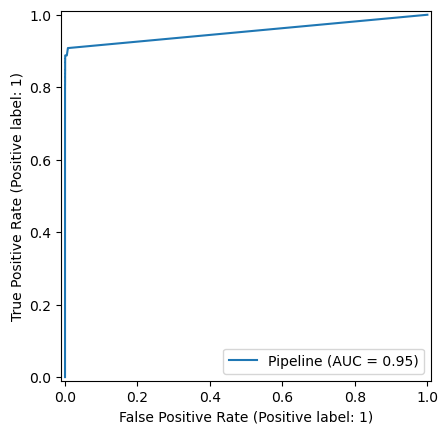

In [ ]:
# Define the pipeline
pipeline_rf=Pipeline([ ('standardize', StandardScaler()),
    ('classifier', RandomForestClassifier())
])

# Define the parameter space for RandomizedSearchCV
# The parameter space is defined as a dictionary where the keys are the names of the parameters and the values are lists of values to be tested for each parameter.
parameter_space = {
    'classifier__min_samples_leaf': [1, 2, 3, 4],
    'classifier__n_estimators': [10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 3, 4, 5],
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__max_depth': [None]
}

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(pipeline_rf, parameter_space, n_iter=10, cv=5, verbose=0, n_jobs=-1)

# Fit the model to the training data
random_search.fit(X_train, Y_train)
# Make predictions on the test set
best_random_forest = random_search.best_estimator_
Y_pred=best_random_forest.predict(X_test)


# Calculate evaluation metrics  
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
ax = RocCurveDisplay.from_estimator(best_random_forest, X_test, Y_test)
roc_auc = roc_auc_score(Y_test, Y_pred)

print(classification_report(Y_test, Y_pred))
print(f"ROC AUC: {roc_auc}")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_}")
print(f"Best estimator: {random_search.best_estimator_}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Save the best estimator (model) from RandomizedSearchCV
pickle.dump(random_search.best_estimator_, open('model.pkl', 'wb'))
# Load the model
loaded_model = pickle.load(open('model.pkl', 'rb'))
# Make predictions with the loaded model
loaded_model_predictions = loaded_model.predict(X_test)
# Calculate evaluation metrics for the loaded model
loaded_model_precision = precision_score(Y_test, loaded_model_predictions)
loaded_model_recall = recall_score(Y_test, loaded_model_predictions)
loaded_model_f1 = f1_score(Y_test, loaded_model_predictions)
print(f"Loaded Model Precision: {loaded_model_precision}")
print(f"Loaded Model Recall: {loaded_model_recall}")
print(f"Loaded Model F1 Score: {loaded_model_f1}")